# Hydro station access through SQL

Edit the configuration cell, then run from a fresh kernel. This notebook reads live
`syndb_hidro` data using `SqlConnector`; Azure device-code sign-in may be requested.
It uses no Spark or Databricks paths. Statistics and duration-curve reporters are deferred.

Historical inventory is resolved from SQL metadata (`Estacao` or `tb_estacao` in `hidro`).
Set `stations_table` to the actual schema-qualified name if your database uses another name.
Daily pivot views must expose `MediaDiaria`, `NivelConsistencia`, and measurement date/value
columns. Telemetry uses the `hidroInfoAna` tables shown in the database inventory.
The SQL schemas and observation column names are checked when queried.

In [1]:
%load_ext autoreload
%autoreload 2

from hydro import Station
from utils.sql_connector import SqlConnector

In [16]:
STATION = 13870000
START = None
END = None

MEASUREMENT = "vazao"
SOURCE = "hidro/telemetria"
SANITIZATION = None

## Connect and load

The two providers borrow one explicitly created connector. The date window is applied
in SQL before observations are downloaded. `end` includes the entire last calendar day.
Rerunning this connection cell requires first running the cleanup cell.

In [17]:
if "connector" not in locals():
    connector = SqlConnector()


In [18]:
station = Station(STATION, connector=connector)

In [19]:
station.available_series()

,code,source,measurement,records
0,13870000,Hidro,cota,33215
1,13870000,Hidro,vazao,21498
2,71564480,Telemetria,cota,3185
3,71564480,Telemetria,vazao,3119


## Station inventory and associated telemetric stations

In [22]:
station.info

,RegistroID,Descricao,Importado,Temporario,Removido,ImportadoRepetido,BaciaCodigo,SubBaciaCodigo,RioCodigo,EstadoCodigo,...,TipoRedeEstrategica,TipoRedeCaptacao,TipoRedeSedimentos,TipoRedeQualAgua,TipoRedeClasseVazao,UltimaAtualizacao,Operando,DataIns,DataAlt,geom_wkb
0,3730062.0,TELEMÉTRICA - VAISALA_GOES\r\nRHNR,0,0,0,0,1,13,13300000,3,...,0,7,1,3,1,2023-09-11,1,None,2023-09-11,b'\x01\x01\x00\x00\x00\xd7\xa3p=\n3P\xc0\xf1c\...


In [20]:
station.name

'LÁBREA'

In [21]:
station.telemetric_info

,OGMORGAO
ESTCODIGO,
71564480,RHN


## Historical data and consistency levels

Historical results include daily means only. Combined data prefer a valid higher-consistency
record on each day. Genuine zero values are retained; null measurements are excluded.

## Telemetry and source merging

Telemetry is averaged by calendar day. RHN has first origin precedence. Historical
observations take precedence over telemetry on overlapping days. An empty telemetry frame
is valid when the station has no associated observations in the requested period.

`Station.get_series()` returns a DataFrame directly, without legacy statistics.

In [24]:
q = station.get_series("hidro/telemetria", "vazao")
q

,EstacaoCodigo,NivelConsistencia,MediaDiaria,vazao_data,val,ano,mes,dia,Sistema,HORESTACAO,ORIGEM
Data,,,,,,,,,,,
1967-07-01,13870000.0,2,1.0,1967-07-01,2629.860107,1967.0,7.0,1.0,Hidro,NaN,NaN
1967-07-02,13870000.0,2,1.0,1967-07-02,2546.629883,1967.0,7.0,2.0,Hidro,NaN,NaN
1967-07-03,13870000.0,2,1.0,1967-07-03,2455.729980,1967.0,7.0,3.0,Hidro,NaN,NaN
1967-07-04,13870000.0,2,1.0,1967-07-04,2384.199951,1967.0,7.0,4.0,Hidro,NaN,NaN
1967-07-05,13870000.0,2,1.0,1967-07-05,2313.729980,1967.0,7.0,5.0,Hidro,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-27,NaN,1,NaN,NaN,1150.882000,NaN,NaN,NaN,Telemetria,71564480.0,RHN
2026-09-28,NaN,1,NaN,NaN,1130.155000,NaN,NaN,NaN,Telemetria,71564480.0,RHN
2026-09-29,NaN,1,NaN,NaN,1126.925000,NaN,NaN,NaN,Telemetria,71564480.0,RHN


## Plot the selected series

Plotting setup belongs to the package. Select a station/date window with observations;
otherwise the method reports that the selected series is empty.

<Axes: title={'center': '13870000 — LÁBREA (hidro/telemetria)'}, xlabel='Data', ylabel='Vazão (m³/s)'>

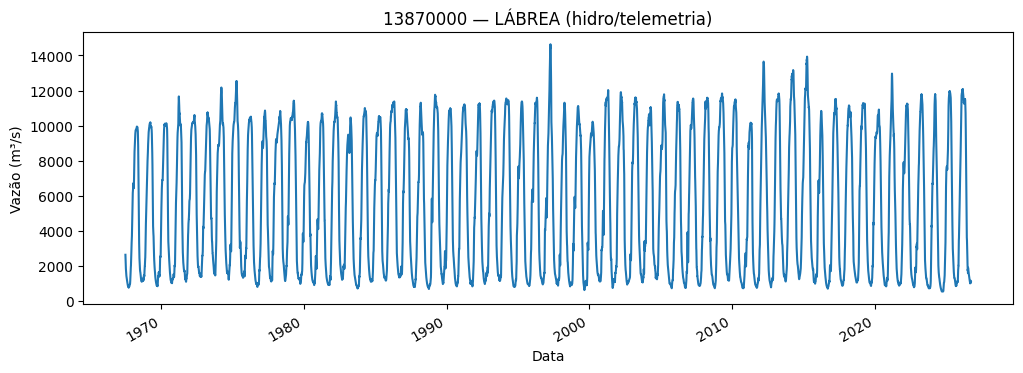

In [25]:
station.plot_series("hidro/telemetria", "vazao")

## Close the connection

The caller owns this connector. Closing the borrowed providers does not close it.
Loaded station frames remain available after cleanup.

In [ ]:
station.close()
connector.close()